# 👋 Welcome to Conformal Prediction with TensorFlow

TensorFlow and `tf.keras` provide a widely used ecosystem for deep learning. In this tutorial, we show how to combine native Keras models with PUNCC to obtain conformal prediction intervals with coverage guarantees under exchangeability.

Unlike the PyTorch tutorial, Keras models already expose `fit` and `predict`, so they work directly with PUNCC's predictors.

-------
Another solution involves using the [IdPredictor](https://deel-ai.github.io/puncc/prediction.html#prediction.IdPredictor), which serves as a placeholder for any model, even those accessible only through API calls. The predictions of the underlying model(s) should be directly passed to puncc for the conformal prediction process, enabling flexible integration with a wide range of models and APIs.

-------

**Table of contents**

- [⚙️ Setup](#tf-setup)
- [💾 Dataset](#tf-data)
- [🔮 Prediction Model](#tf-pm)
- [⏸️ Conformal Prediction with SplitCP](#tf-splitcp)
- [🤞 Conformal Prediction with CV+](#tf-cvplus)
- [〽️ Conformal Prediction with CQR](#tf-cqr)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)


### ⚙️ Setup  <a class="anchor" id="tf-setup"></a>


First, ensure we have the necessary libraries installed. You can install them if needed using pip:


In [2]:
# !pip install puncc tensorflow

We import the required libraries and define `evaluate_cp`, a helper that computes the average width and coverage of prediction intervals on a test set for a chosen risk level $\alpha$.


In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import warnings
import tensorflow as tf
import matplotlib.pyplot as plt

from deel.puncc.metrics import regression_mean_coverage, regression_sharpness

warnings.filterwarnings("ignore")
tf.keras.utils.set_random_seed(0)


def evaluate_cp(X_test, y_test, model_cp, alpha):
    """Compute sharpness and marginal coverage for a conformal regressor."""
    _, y_pred_lower, y_pred_upper = model_cp.predict(X_test, alpha=alpha)
    sharpness = regression_sharpness(y_pred_lower.numpy(), y_pred_upper.numpy())
    coverage = regression_mean_coverage(
        y_test[:, 0].numpy(), y_pred_lower.numpy(), y_pred_upper.numpy()
    )
    return sharpness, coverage

### 💾 Dataset <a class="anchor" id="tf-data"></a>


We consider a synthetic 1D heteroskedastic regression dataset, where the noise variance increases with the input value.


2026-06-20 15:48:19.561798: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


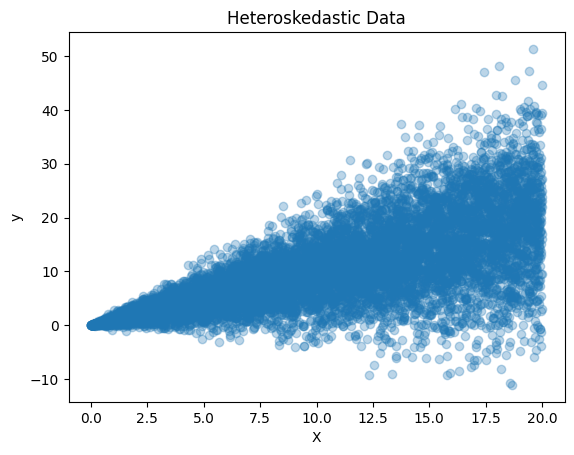

In [2]:
import tensorflow as tf

n_samples = 10000

X = tf.linspace(0.0, 20.0, n_samples)
X = tf.reshape(X, (-1, 1))
X = tf.cast(X, tf.float32)

tf.random.set_seed(0)
noise = tf.random.normal(shape=(n_samples,), dtype=tf.float32) * X[:, 0] * 0.5

y = tf.cast(X[:, 0] + noise, tf.float32)
y = tf.expand_dims(tf.cast(X[:, 0] + noise, tf.float32), axis=-1)

indices = tf.range(n_samples)
indices = tf.random.shuffle(indices, seed=0)

test_size = int(0.3 * n_samples)
test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = tf.gather(X, train_indices)
X_test = tf.gather(X, test_indices)
y_train = tf.gather(y, train_indices)
y_test = tf.gather(y, test_indices)


plt.scatter(X[:, 0], y, alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Heteroskedastic Data")
plt.show()

By construction, the samples are i.i.d., which matches the usual assumptions required by conformal prediction.


### 🔮 Prediction Model <a class="anchor" id="tf-pm"></a>

We define a small Keras regressor. Because `tf.keras.Model` already provides `fit` and `predict`, PUNCC can wrap it directly.


In [3]:
def build_regression_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(1),
        ]
    )

There exist different conformal prediction methods tailored to specific needs. In each method, the underlying model(s) are wrapped by PUNCC to standardize training and inference.

<br/><br/>
<div align='center'>

| Conformal Prediction Method | Model Wrapper |
|-----------------------------|---------------|
| SplitCP                     | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |
| CVPlus                      | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |
| LocallyAdaptiveCP           | [`MeanVarPredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.MeanVarPredictor) |
| EnbPI                       | [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |
| CQR                         | [`DualPredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.DualPredictor) |
| APS or RAPS (classification)| [`BasePredictor`](https://deel-ai.github.io/puncc/prediction.html#prediction.BasePredictor) |

<caption>
Table 1: Model Wrappers for Different Conformal Prediction Methods in PUNCC
</caption>

</div>

<br/>

*📓 Note: puncc also enables fully custom [Predictor](https://deel-ai.github.io/puncc/api.html#predictor)(s). To learn more about the low-level API, check [this tutorial](https://github.com/deel-ai/puncc/blob/main/docs/api_intro.ipynb).*


In the following sections, we will apply Split Conformal Prediction (SplitCP), Conformal Cross-Validation Plus (CV+), and Conformalized Quantile Regression (CQR) with TensorFlow models.


### ⏸️ Conformal Prediction with SplitCP <a class="anchor" id="tf-splitcp"></a>

Split conformal prediction trains a model on one subset and uses a disjoint calibration subset to turn point predictions into prediction intervals with target coverage $1-\alpha$.


In [4]:
from deel.puncc.api.prediction import BasePredictor
from deel.puncc.regression import SplitCP

base_predictor = BasePredictor(
    build_regression_model(),
    is_trained=False,
    optimizer="adam",
    loss="mse",
)

splitcp = SplitCP(base_predictor, train=True, random_state=0)
splitcp.fit(
    X=X_train,
    y=y_train,
    fit_ratio=0.5,
    epochs=20,
    batch_size=64,
    verbose=1,
)

Epoch 1/20
55/55 [==============================] - 0s 632us/step - loss: 73.5615
Epoch 2/20
55/55 [==============================] - 0s 626us/step - loss: 33.5002
Epoch 3/20
55/55 [==============================] - 0s 549us/step - loss: 33.5489
Epoch 4/20
55/55 [==============================] - 0s 521us/step - loss: 33.4686
Epoch 5/20
55/55 [==============================] - 0s 524us/step - loss: 33.5271
Epoch 6/20
55/55 [==============================] - 0s 523us/step - loss: 33.5325
Epoch 7/20
55/55 [==============================] - 0s 523us/step - loss: 33.5084
Epoch 8/20
55/55 [==============================] - 0s 521us/step - loss: 33.5264
Epoch 9/20
55/55 [==============================] - 0s 521us/step - loss: 33.5198
Epoch 10/20
55/55 [==============================] - 0s 517us/step - loss: 33.5070
Epoch 11/20
55/55 [==============================] - 0s 518us/step - loss: 33.6126
Epoch 12/20
55/55 [==============================] - 0s 515us/step - loss: 33.4960
Epoch 13/20
5

Now let us evaluate the resulting intervals for a target risk of $\alpha = 10\%$ and visualize them on the test set.


In [5]:
X_test[:, 0].numpy().shape

(3000,)

 1/94 [..............................] - ETA: 2s

94/94 [==============================] - 0s 311us/step
Average prediction interval width (sharpness): 19.582
Average coverage: 0.900


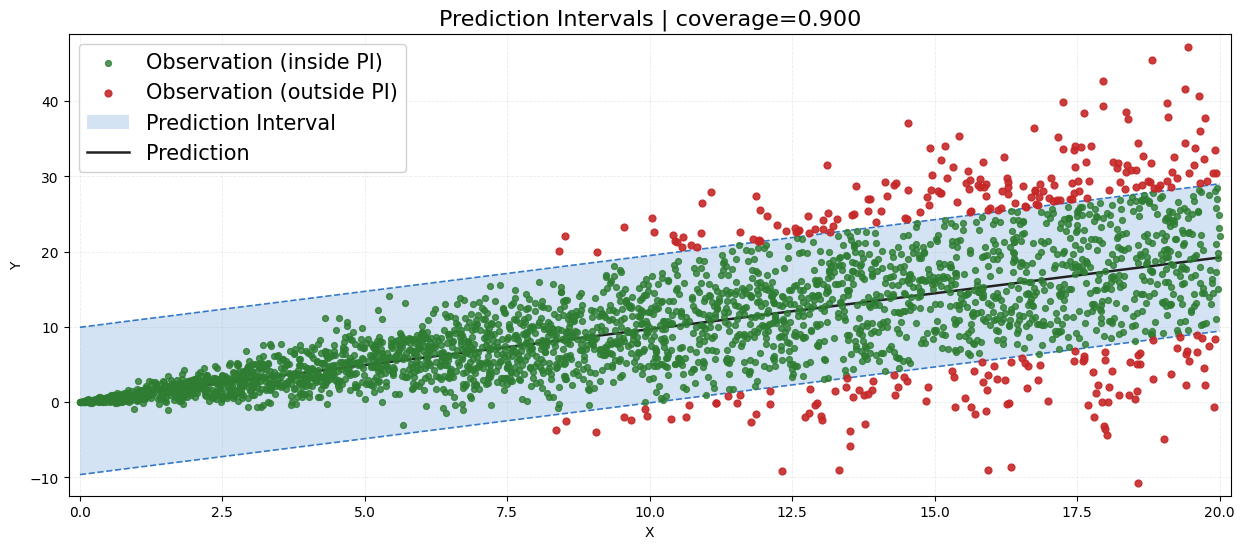

In [6]:
from deel.puncc.plotting import plot_prediction_intervals

alpha = 0.1

y_pred, y_pred_lower, y_pred_upper = splitcp.predict(X_test, alpha=alpha)
sharpness, coverage = evaluate_cp(X_test, y_test, splitcp, alpha)
print(f"Average prediction interval width (sharpness): {sharpness:.3f}")
print(f"Average coverage: {coverage:.3f}")

plot_prediction_intervals(
    y_true=y_test[:, 0].numpy(),
    y_pred_lower=y_pred_lower.numpy(),
    y_pred_upper=y_pred_upper.numpy(),
    y_pred=y_pred.numpy(),
    X=X_test[:, 0].numpy(),
)
plt.show()

### 🤞 Conformal Prediction with CV+ <a class="anchor" id="tf-cvplus"></a>

CV+ replaces a single fit/calibration split with multiple folds. This often makes better use of the available data while still delivering rigorous predictive intervals.


94/94 [==============================] - 0s 326us/step
Average prediction interval width (sharpness): 19.420
Average coverage: 0.899


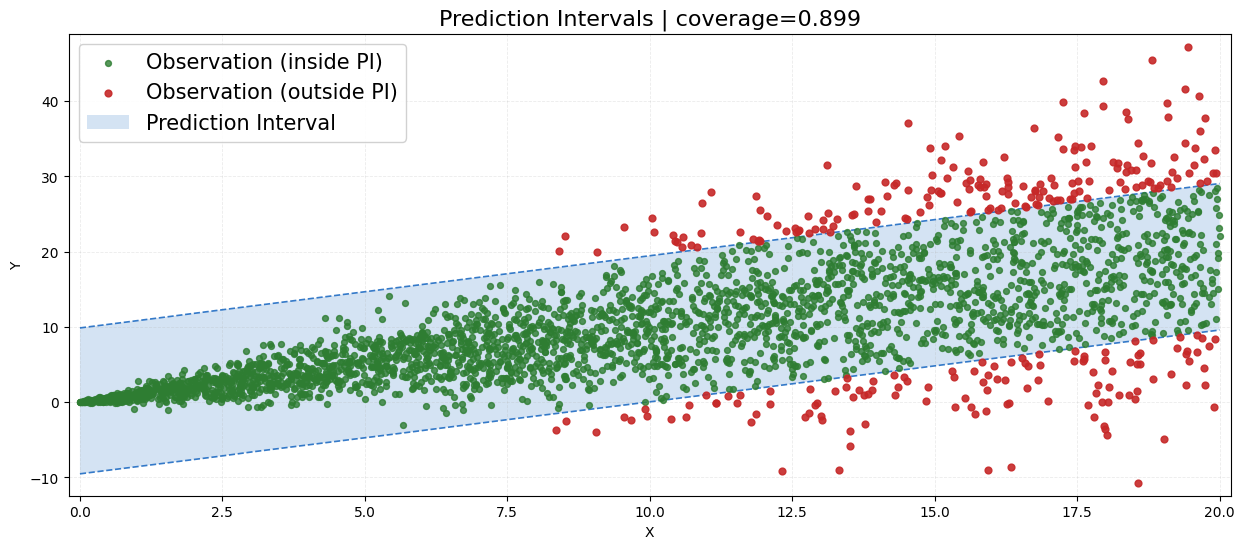

In [7]:
from deel.puncc.regression import CVPlus

cv_predictor = BasePredictor(
    build_regression_model(),
    is_trained=False,
    optimizer="adam",
    loss="mse",
)

cvplus = CVPlus(cv_predictor, K=5, random_state=0)
cvplus.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)

y_pred, y_pred_lower, y_pred_upper = cvplus.predict(X_test, alpha=alpha)
sharpness, coverage = evaluate_cp(X_test, y_test, cvplus, alpha)
print(f"Average prediction interval width (sharpness): {sharpness:.3f}")
print(f"Average coverage: {coverage:.3f}")

plot_prediction_intervals(
    y_true=y_test[:, 0].numpy(),
    y_pred_lower=y_pred_lower.numpy(),
    y_pred_upper=y_pred_upper.numpy(),
    y_pred=None,
    X=X_test[:, 0].numpy(),
)
plt.show()

### 〽️ Conformal Prediction with CQR <a class="anchor" id="tf-cqr"></a>

Conformalized Quantile Regression combines quantile regression with conformal calibration. We will train two TensorFlow models, one for the lower quantile and one for the upper quantile, then conformalize their outputs with `CQR`.


In [8]:
class PinballLoss(tf.keras.losses.Loss):
    def __init__(
        self,
        tau,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name="pinball_loss",
    ):
        super().__init__(reduction=reduction, name=name)
        self.tau = tau

    def call(self, y_true, y_pred):
        errors = y_true - y_pred
        loss = tf.maximum(self.tau * errors, (self.tau - 1) * errors)
        return tf.reduce_mean(loss, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({"tau": self.tau})
        return config


def build_quantile_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(1),
        ]
    )

We split the training data into a proper fit set and a calibration set, then let PUNCC train both quantile models through a `DualPredictor`.


94/94 [==============================] - 0s 335us/step
Average prediction interval width (sharpness): 16.296
Average coverage: 0.883


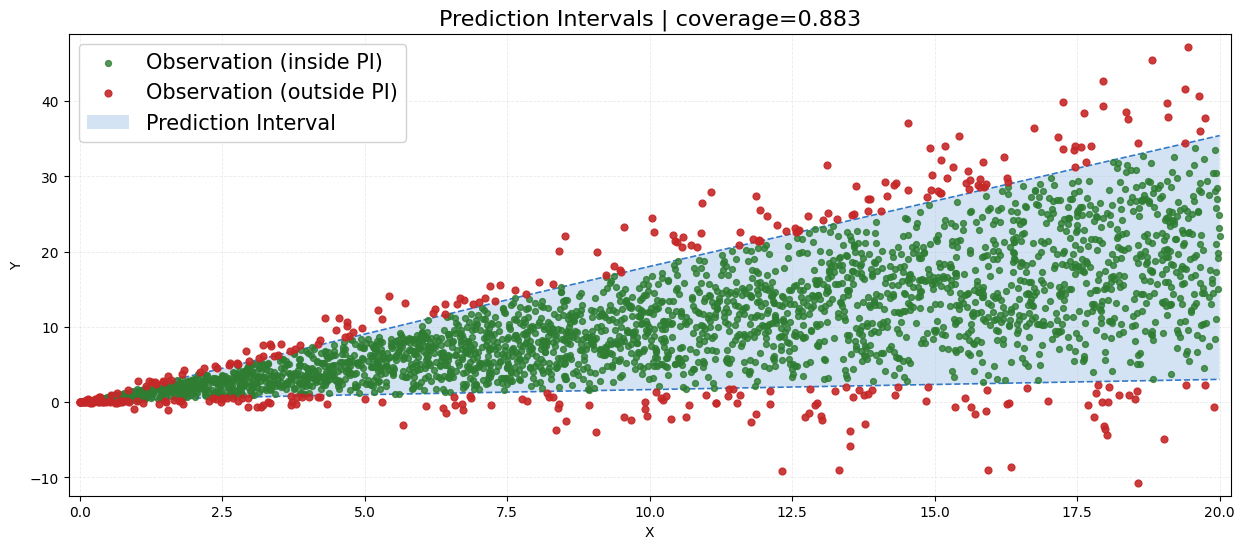

In [9]:
from deel.puncc.api.prediction import DualPredictor
from deel.puncc.regression import CQR

X_fit, X_calib, y_fit, y_calib = (
    X_train[:5000, :],
    X_train[5000:, :],
    y_train[:5000, 0],
    y_train[5000:, 0],
)
dual_predictor = DualPredictor(
    models=[build_quantile_model(), build_quantile_model()],
    compile_args=[
        {"optimizer": "adam", "loss": PinballLoss(alpha / 2)},
        {"optimizer": "adam", "loss": PinballLoss(1 - alpha / 2)},
    ],
)

cqr = CQR(dual_predictor, train=True)
cqr.fit(
    X_fit=X_fit,
    y_fit=y_fit,
    X_calib=X_calib,
    y_calib=y_calib,
    dictargs=[
        {"epochs": 30, "batch_size": 64, "verbose": 0},
        {"epochs": 30, "batch_size": 64, "verbose": 0},
    ],
)

y_pred, y_pred_lower, y_pred_upper = cqr.predict(X_test, alpha=alpha)
sharpness, coverage = evaluate_cp(X_test, y_test, cqr, alpha)
print(f"Average prediction interval width (sharpness): {sharpness:.3f}")
print(f"Average coverage: {coverage:.3f}")

plot_prediction_intervals(
    y_true=y_test[:, 0].numpy(),
    y_pred_lower=y_pred_lower.numpy(),
    y_pred_upper=y_pred_upper.numpy(),
    y_pred=None,
    X=X_test[:, 0].numpy(),
)
plt.show()

# 🎉 Congratulations
**You now know how to perform conformal prediction with TensorFlow models.**

Because Keras models already implement `fit` and `predict`, integrating them with PUNCC is mostly about choosing the right predictor wrapper and compile configuration. If your model lives behind an API or uses a custom inference surface, you can still integrate it through [IdPredictor](https://deel-ai.github.io/puncc/prediction.html#prediction.IdPredictor) or by defining your own [Predictor](https://deel-ai.github.io/puncc/api.html#predictor).
